<a href="https://colab.research.google.com/github/DawerSP/Inteligencia-Aritificial/blob/main/Taller7_11ConPunto5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

df_creditos = pd.read_csv('creditos.csv')


X = df_creditos[['edad', 'credito']]
y = df_creditos['cumplio']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn_euclidean = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_euclidean.fit(X_train_scaled, y_train)

print("--- Modelo Base (Euclidiana, k=3) ---")

y_pred_euclidean = knn_euclidean.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_euclidean))
print(classification_report(y_test, y_pred_euclidean))

--- Modelo Base (Euclidiana, k=3) ---
[[ 2  3]
 [ 0 35]]
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.92      1.00      0.96        35

    accuracy                           0.93        40
   macro avg       0.96      0.70      0.77        40
weighted avg       0.93      0.93      0.91        40



In [2]:

print("\n--- Modelo con Distancia Manhattan (k=3) ---")
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_manhattan.fit(X_train_scaled, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_manhattan))
print(classification_report(y_test, y_pred_manhattan))


print("\n--- Modelo con Distancia Minkowski (p=3, k=3) ---")
knn_minkowski_3 = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=3)
knn_minkowski_3.fit(X_train_scaled, y_train)
y_pred_minkowski_3 = knn_minkowski_3.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_minkowski_3))
print(classification_report(y_test, y_pred_minkowski_3))


--- Modelo con Distancia Manhattan (k=3) ---
[[ 1  4]
 [ 0 35]]
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.90      1.00      0.95        35

    accuracy                           0.90        40
   macro avg       0.95      0.60      0.64        40
weighted avg       0.91      0.90      0.87        40


--- Modelo con Distancia Minkowski (p=3, k=3) ---
[[ 2  3]
 [ 0 35]]
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.92      1.00      0.96        35

    accuracy                           0.93        40
   macro avg       0.96      0.70      0.77        40
weighted avg       0.93      0.93      0.91        40



####PUNTO 4

k = 3, Precisión (Accuracy) = 0.9250
k = 5, Precisión (Accuracy) = 0.9000
k = 9, Precisión (Accuracy) = 0.8750
k = 15, Precisión (Accuracy) = 0.8750
k = 21, Precisión (Accuracy) = 0.8750


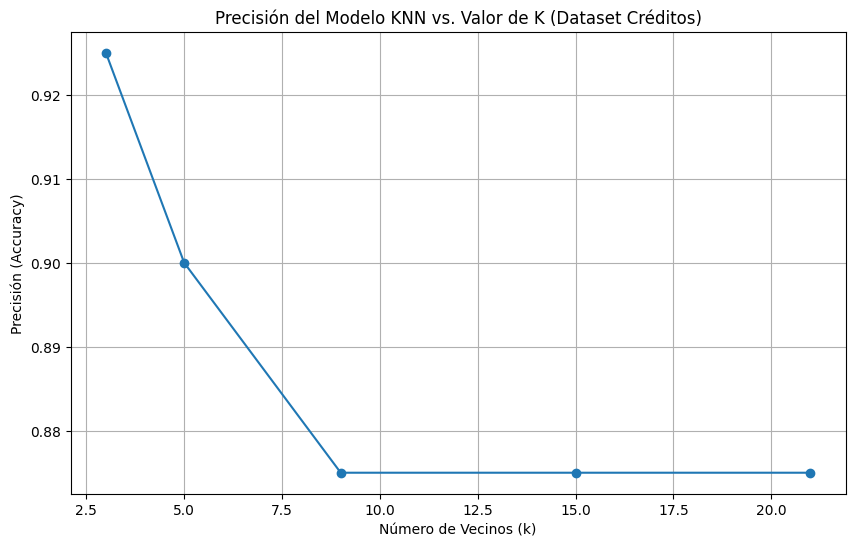

In [3]:
import matplotlib.pyplot as plt


k_values = [3, 5, 9, 15, 21]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)
    accuracies.append(accuracy)
    print(f"k = {k}, Precisión (Accuracy) = {accuracy:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Precisión del Modelo KNN vs. Valor de K (Dataset Créditos)')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Precisión (Accuracy)')
plt.grid(True)
plt.show()

TAREA 5

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer


df_reviews = pd.read_csv('reviews_sentiment.csv', delimiter=';')


df_reviews = df_reviews.dropna(subset=['Review Text', 'textSentiment'])

X_text = df_reviews['Review Text']
y_sentiment = df_reviews['textSentiment']


X_train_text, X_test_text, y_train_sent, y_test_sent = train_test_split(
    X_text, y_sentiment, test_size=0.2, random_state=42
)


tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

X_test_tfidf = tfidf_vectorizer.transform(X_test_text)


knn_sentiment = KNeighborsClassifier(n_neighbors=15, metric='euclidean')
knn_sentiment.fit(X_train_tfidf, y_train_sent)

print("\n--- Modelo KNN para 'reviews_sentiment.csv' (k=15) ---")
y_pred_sentiment = knn_sentiment.predict(X_test_tfidf)
print(confusion_matrix(y_test_sent, y_pred_sentiment))
print(classification_report(y_test_sent, y_pred_sentiment))


--- Modelo KNN para 'reviews_sentiment.csv' (k=15) ---
[[ 0 13]
 [ 0 39]]
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        13
    positive       0.75      1.00      0.86        39

    accuracy                           0.75        52
   macro avg       0.38      0.50      0.43        52
weighted avg       0.56      0.75      0.64        52



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

df_reviews = pd.read_csv('reviews_sentiment.csv', delimiter=';')

df_reviews = df_reviews.dropna(subset=['Review Text', 'textSentiment'])

X_text = df_reviews['Review Text']
y_sentiment_str = df_reviews['textSentiment']

label_encoder = LabelEncoder()
y_sentiment_encoded = label_encoder.fit_transform(y_sentiment_str)

target_names = label_encoder.classes_

X_train_text, X_test_text, y_train_sent, y_test_sent = train_test_split(
    X_text, y_sentiment_encoded, test_size=0.2, random_state=42
)


tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("Variables de datos y 'target_names' definidas correctamente. ")

Variables de datos y 'target_names' definidas correctamente. ✅


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

k_value = 15

print("\n--- Tarea 5.1: Comparación de Distancias en Análisis de Sentimiento (CORREGIDO) ---")


metrics_to_test = [
    ('euclidean', 'Euclidiana'),
    ('manhattan', 'Manhattan'),
    ('minkowski', 'Minkowski (p=3)')
]

best_f1 = -1
best_metric = ''

for metric, name in metrics_to_test:

    knn_params = {
        'n_neighbors': k_value,
        'metric': metric,
        'algorithm': 'brute'
    }


    if metric == 'minkowski':
        knn_params['p'] = 3


    knn = KNeighborsClassifier(**knn_params)


    knn.fit(X_train_tfidf, y_train_sent)
    y_pred = knn.predict(X_test_tfidf)

    report = classification_report(y_test_sent, y_pred, target_names=target_names, output_dict=True)
    f1_score = report['macro avg']['f1-score']

    print(f"\n--- Reporte con Distancia {name} (k={k_value}) ---")
    print(classification_report(y_test_sent, y_pred, target_names=target_names))

    if f1_score > best_f1:
        best_f1 = f1_score
        best_metric = metric

print(f"\n✅ Mejor Métrica elegida (por F1-score): '{best_metric}' con F1={best_f1:.4f}")


--- Tarea 5.1: Comparación de Distancias en Análisis de Sentimiento (CORREGIDO) ---

--- Reporte con Distancia Euclidiana (k=15) ---
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        13
    positive       0.75      1.00      0.86        39

    accuracy                           0.75        52
   macro avg       0.38      0.50      0.43        52
weighted avg       0.56      0.75      0.64        52


--- Reporte con Distancia Manhattan (k=15) ---
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        13
    positive       0.75      1.00      0.86        39

    accuracy                           0.75        52
   macro avg       0.38      0.50      0.43        52
weighted avg       0.56      0.75      0.64        52



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

ValueError: Metric 'minkowski' not valid for sparse input. Use sorted(sklearn.neighbors.VALID_METRICS_SPARSE['brute']) to get valid options. Metric can also be a callable function.

In [7]:



best_metric = 'euclidean'
k_values_sentiment = [1, 51, 101, 161, 201] # 5 valores de k, incluyendo la raíz cuadrada (161)
accuracies_sentiment = []

print(f"\n--- Probando 5 valores de k con la métrica: {best_metric} ---")

for k in k_values_sentiment:
    knn = KNeighborsClassifier(n_neighbors=k, metric=best_metric)
    knn.fit(X_train_tfidf, y_train_sent)
    accuracy = knn.score(X_test_tfidf, y_test_sent)
    accuracies_sentiment.append(accuracy)
    print(f"k = {k}, Precisión (Accuracy) = {accuracy:.4f}")




--- Probando 5 valores de k con la métrica: euclidean ---
k = 1, Precisión (Accuracy) = 0.7500
k = 51, Precisión (Accuracy) = 0.7500
k = 101, Precisión (Accuracy) = 0.7500
k = 161, Precisión (Accuracy) = 0.7500
k = 201, Precisión (Accuracy) = 0.7500
